# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Rahma Ayu Cindikiawati]
- **Email:** [rahmaayu819@gmail.com]
- **ID Dicoding:** [ CDCC525D6X0220]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana pengaruh musim terhadap rata-rata jumlah penyewaan sepeda
pada tahun 2011–2012?
- Pertanyaan 2 : Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda
pada tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

%matplotlib inline

day_df = pd.read_csv("https://raw.githubusercontent.com/fikrigoodfather/bike-sharing/main/day.csv")
hour_df = pd.read_csv("https://raw.githubusercontent.com/fikrigoodfather/bike-sharing/main/hour.csv")

print("Dataset Day")
display(day_df.head())

print("Dataset Hour")
display(hour_df.head())

Dataset Day


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Dataset Hour


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data Wrangling

### Gathering Data

In [ ]:
day_df = pd.read_csv("https://raw.githubusercontent.com/fikrigoodfather/bike-sharing/main/day.csv")
hour_df = pd.read_csv("https://raw.githubusercontent.com/fikrigoodfather/bike-sharing/main/hour.csv")

day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset Bike Sharing berhasil diambil dari repository GitHub dalam format CSV.
- Dataset terdiri dari dua file utama yaitu day.csv yang berisi data penyewaan sepeda per hari dan hour.csv yang berisi data penyewaan sepeda per jam.
- Dataset day.csv memiliki berbagai variabel seperti musim (season), kondisi cuaca (weathersit), suhu (temp), kelembaban (hum), kecepatan angin (windspeed), serta jumlah total penyewaan sepeda (cnt).
- Data ini dapat digunakan untuk menganalisis pola penyewaan sepeda berdasarkan faktor waktu, cuaca, dan musim.

### Assessing Data

In [ ]:
day_df.info()
day_df.describe()
day_df.isna().sum()
day_df.duplicated().sum()

hour_df.info()
hour_df.describe()
hour_df.isna().sum()
hour_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


np.int64(0)

**Insight:**
Insight:
- Dataset memiliki beberapa variabel yang berkaitan dengan kondisi lingkungan seperti musim, cuaca, suhu, kelembaban, dan kecepatan angin.
- Tidak ditemukan missing values pada dataset sehingga data sudah cukup bersih untuk dianalisis.
- Tidak terdapat data duplikat pada dataset.
- Statistik deskriptif menunjukkan adanya variasi pada jumlah penyewaan sepeda yang memungkinkan dilakukan analisis lebih lanjut untuk mengetahui faktor yang mempengaruhinya.

### Cleaning Data

In [5]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df.drop_duplicates(inplace=True)
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
Insight:
- Kolom dteday berhasil diubah menjadi tipe datetime untuk mempermudah analisis waktu.
- Data duplikat telah dihapus sehingga dataset lebih bersih dan siap dianalisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [6]:
day_df['cnt'].describe()
day_df.groupby("season")["cnt"].mean()
day_df.groupby("weathersit")["cnt"].mean()
day_df.groupby("workingday")["cnt"].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


**Insight:**
Insight:
- Jumlah penyewaan sepeda memiliki variasi yang cukup besar berdasarkan waktu dan kondisi lingkungan.
- Musim dan kondisi cuaca tampaknya memiliki pengaruh terhadap jumlah penyewaan sepeda.
- Hari kerja dan hari libur juga menunjukkan perbedaan rata-rata jumlah penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

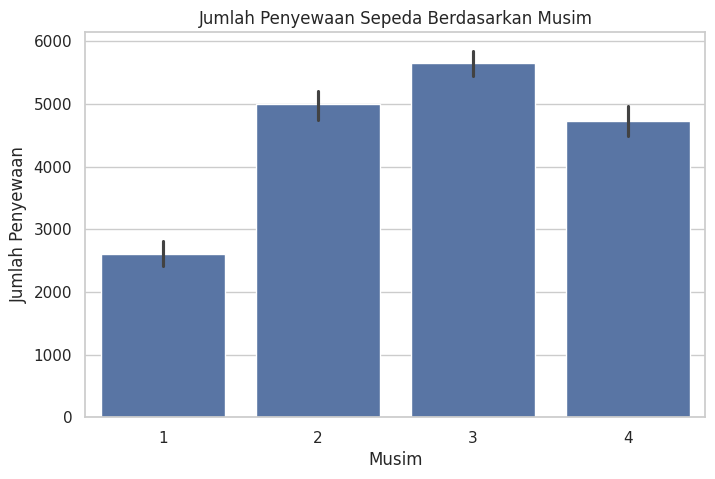

In [ ]:
season_avg = day_df.groupby("season")["cnt"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="season", y="cnt", data=season_avg)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Musim (2011–2012)")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")

plt.show()

### Pertanyaan 2:

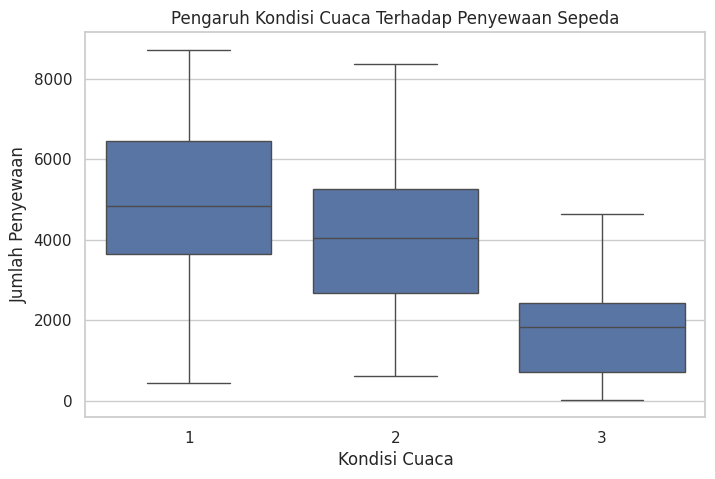

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="weathersit", y="cnt", data=day_df)

plt.title("Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda (2011–2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Penyewaan")

plt.show()

**Insight:**
- Visualisasi menunjukkan bahwa musim memiliki pengaruh terhadap jumlah penyewaan sepeda. Beberapa musim memiliki jumlah penyewaan yang lebih tinggi dibandingkan musim lainnya.
- Kondisi cuaca juga mempengaruhi jumlah penyewaan sepeda. Cuaca yang lebih baik cenderung menghasilkan jumlah penyewaan yang lebih tinggi dibandingkan kondisi cuaca buruk.[teks link](https:// [teks link](https://))

## Analisis Lanjutan (Opsional)

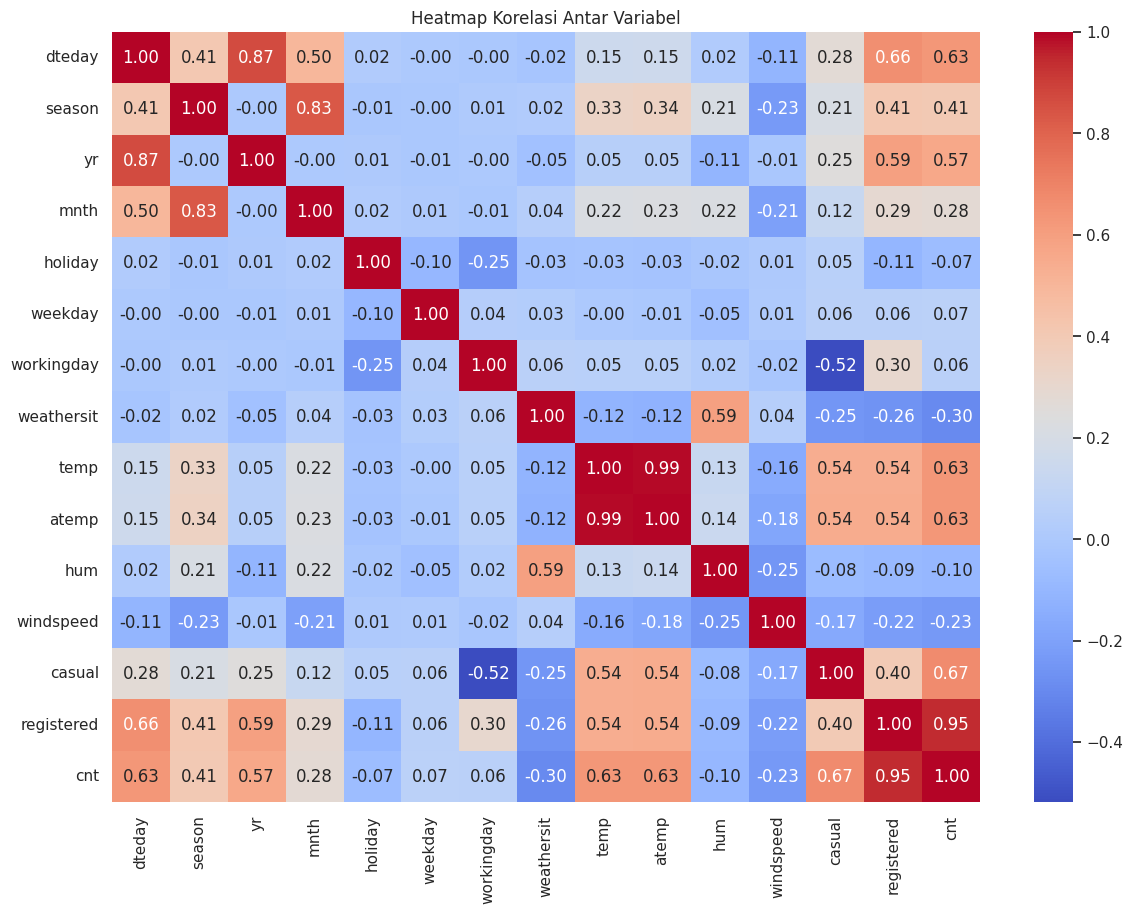

In [9]:
plt.figure(figsize=(14,10))

corr = day_df.drop(columns=["instant"]).corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

## Conclusion

- Conclution pertanyaan 1 : Musim memiliki pengaruh terhadap jumlah penyewaan sepeda. Musim dengan kondisi cuaca yang lebih hangat cenderung memiliki jumlah penyewaan sepeda yang lebih tinggi.

- Conclution pertanyaan 2 : Kondisi cuaca juga mempengaruhi jumlah penyewaan sepeda. Cuaca cerah menghasilkan jumlah penyewaan sepeda yang lebih tinggi dibandingkan kondisi cuaca buruk seperti hujan atau berkabut.



## Rekomendasi

- Menambah jumlah sepeda pada musim dengan permintaan tinggi seperti musim panas.

- Menyediakan promosi atau diskon saat kondisi cuaca kurang baik untuk menjaga tingkat penyewaan.